# TP 7 - Reducción de la dimensión

## Predecir retrasos en los vuelos
El dataset contiene 400.000+ registros, cada uno con 21 atributos, de vuelos realizados entre el 1/1/19 y el 31/1/19. El objetivo es predecir las demoras o retrasos de un vuelo en particular.ctWNF

In [1]:
import numpy as np
import pandas as pd
import os
import requests
import time
import re
import string
from urllib.parse import urlparse


from tqdm import tqdm
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from glob import glob
from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

from sklearn.utils.multiclass import type_of_target
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    average_precision_score,
    precision_recall_curve
)

import umap

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


from joblib import dump, load
import warnings

warnings.filterwarnings("ignore")

C:\Users\pablonicolasr\anaconda3\envs\am_uns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_data = os.path.join(os.getcwd(), "data")
path = Path(path_data)
path.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(os.path.join(os.getcwd(), "data", "ml_project1_data.csv"))

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [6]:
TARGET_COL = None

In [7]:
print("="*80)
print("Shape:", df.shape)
print("="*80)
display(df.head())
print("="*80)
display(df.info())
print("="*80)

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

None

## Analizamos valores faltantes

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columnas con NA:")
display(missing)

Columnas con NA:


Income    24
dtype: int64

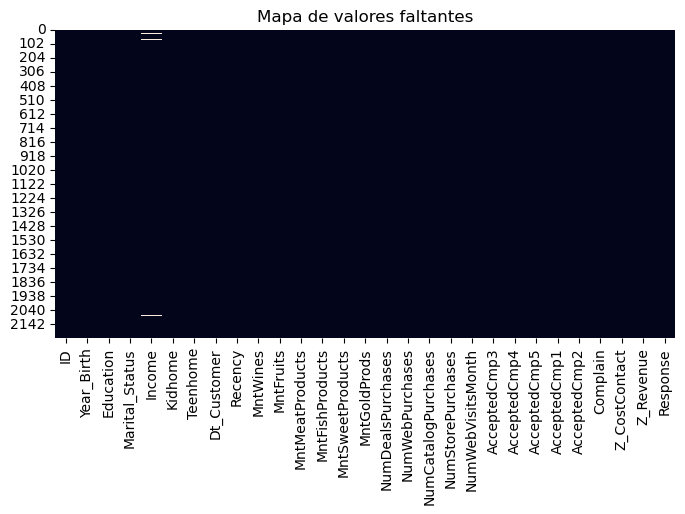

In [9]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.show()

## Analizamos el tipo de variable en cada columna

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 26
Categóricas: 3


## Realizamos estadística descriptiva

In [11]:
print("Estadística numérica:")
display(df[num_cols].describe().T)

if len(cat_cols) > 0:
    print("\nVariables categóricas:")
    for col in cat_cols:
        print("\n", col)
        display(df[col].value_counts().head())

Estadística numérica:


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0



Variables categóricas:

 Education


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


 Marital_Status


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Name: count, dtype: int64


 Dt_Customer


Dt_Customer
2012-08-31    12
2014-05-12    11
2012-09-12    11
2013-02-14    11
2014-05-22    10
Name: count, dtype: int64

## Se analizará la columna "objetivo"

In [12]:
y = df["Response"]
print("Tipo de target:", type_of_target(y))

Tipo de target: binary


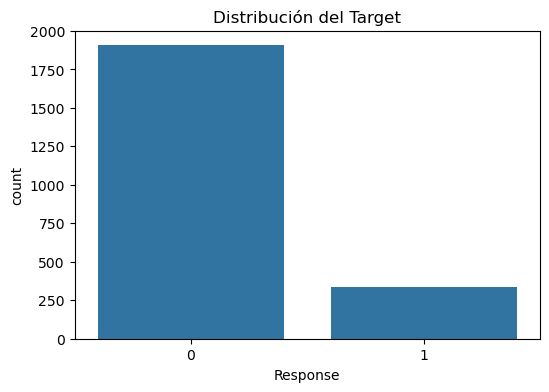

In [13]:
plt.figure(figsize=(6,4))

if type_of_target(y) in ["binary", "multiclass"]:
    sns.countplot(x=y)
    plt.title("Distribución del Target")

In [14]:
df["Response"].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

## Analizamos correlación

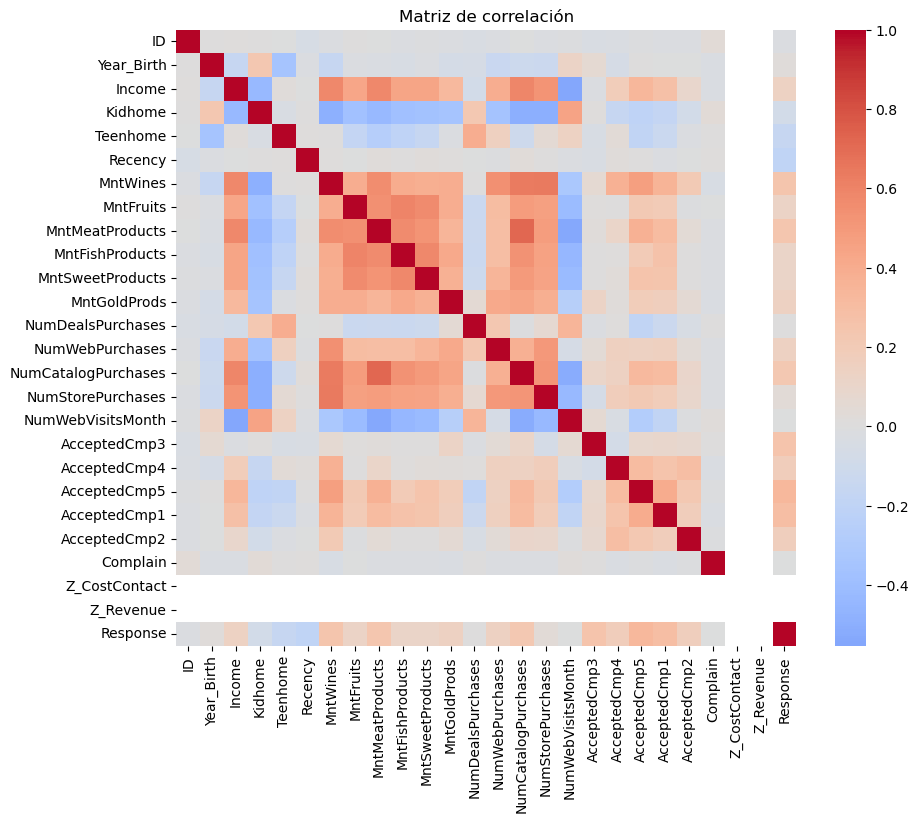


Correlación con target:
Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Z_CostContact               NaN
Z_Revenue                   NaN
Name: Response, dtype: float64


In [15]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

# Correlación con target si es numérico
if "Response" in num_cols:
    print("\nCorrelación con target:")
    print(corr["Response"].sort_values(ascending=False))

## Analizamos valores atípicos

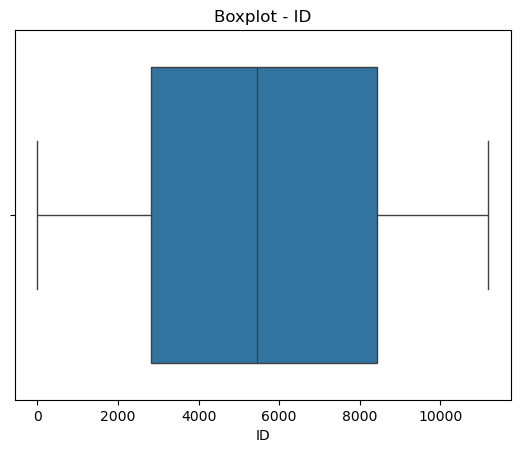

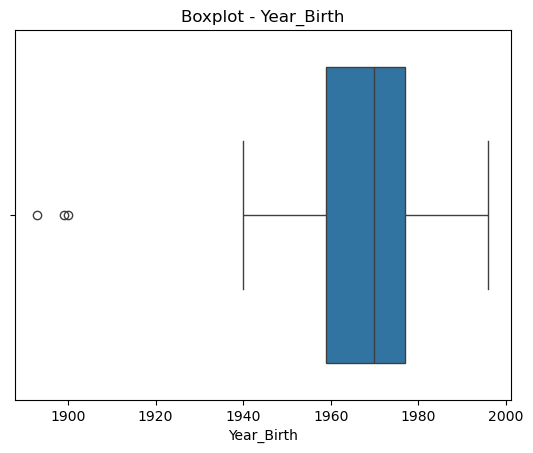

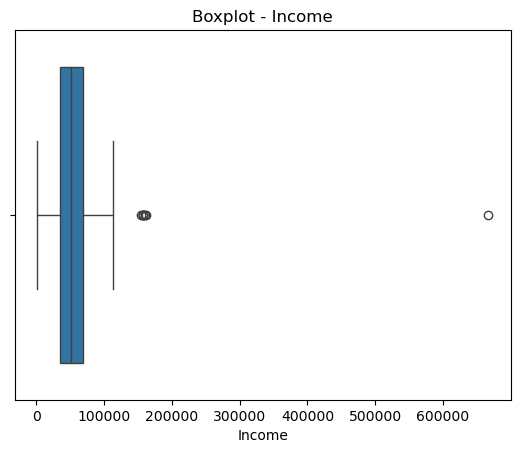

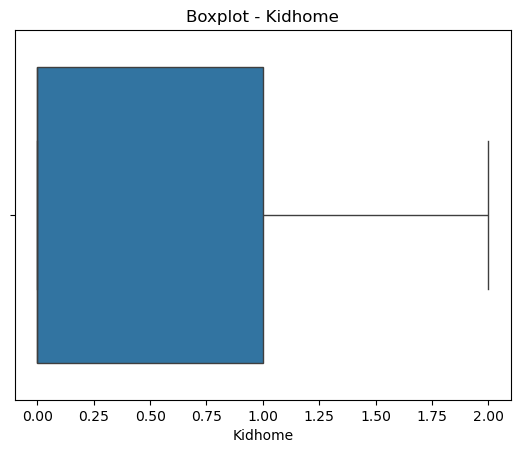

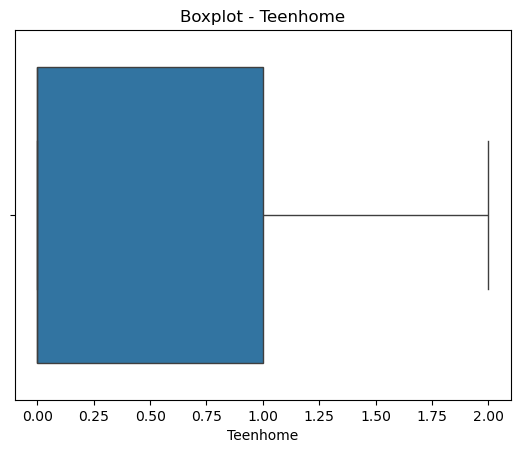

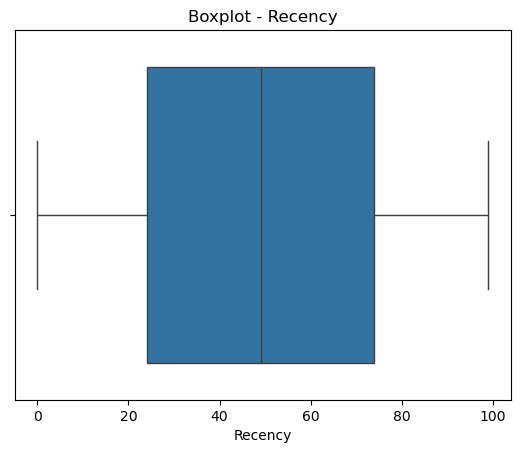

In [16]:
for col in num_cols[:6]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Variance Inflation Factor (VIF)

## ¿Qué es el VIF?

El **Variance Inflation Factor (VIF)** es una métrica utilizada para detectar **multicolinealidad** entre variables explicativas en un modelo de regresión.

La multicolinealidad ocurre cuando una variable puede ser explicada linealmente por otras variables del dataset.

---

## Definición matemática

Para cada variable \( X_i \), el VIF se define como:

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Donde:

- $$( R_i^2 )$$ es el coeficiente de determinación de la regresión donde:
  
  $$
  X_i = f(X_{1}, X_{2}, ..., X_{i-1}, X_{i+1}, ..., X_{p})
  $$

Es decir, se regresa cada variable contra todas las demás.

---

## Interpretación del VIF

| Valor VIF | Interpretación |
|------------|----------------|
| 1 | Sin colinealidad |
| 1 – 5 | Colinealidad leve |
| 5 – 10 | Colinealidad moderada |
| > 10 | Colinealidad fuerte  |

Un VIF alto indica que la variable contiene información redundante.

---



In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X_vif = df[num_cols].dropna()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF:")
display(vif_data.sort_values("VIF", ascending=False))


VIF:


,feature,VIF
6,MntWines,3.354070
14,NumCatalogPurchases,3.112314
8,MntMeatProducts,3.079459
15,NumStorePurchases,2.443599
16,NumWebVisitsMonth,2.363545
2,Income,2.209313
9,MntFishProducts,2.128605
13,NumWebPurchases,1.991775
7,MntFruits,1.952965
10,MntSweetProducts,1.922341


# Interpretación de VIF

## Resultados obtenidos

El cálculo del Variance Inflation Factor (VIF) arrojó los siguientes valores:

- VIF máximo ≈ **3.35**
- La mayoría de variables se encuentran entre **1 y 3**
- Dos variables presentan VIF = 0

---

## Análisis técnico

### Nivel general de colinealidad

No se observa multicolinealidad fuerte.

Recordemos la interpretación estándar:

- VIF < 5 → colinealidad leve
- VIF > 10 → colinealidad problemática

En este dataset:

$$
\max(VIF) = 3.35
$$

Esto indica que **no existe colinealidad estructural severa** entre variables.

---

### Variables con mayor VIF

Las variables con mayor colinealidad relativa son:

- `MntWines`
- `NumCatalogPurchases`
- `MntMeatProducts`

Esto es coherente desde el punto de vista del negocio:

- Gastos en distintos productos suelen correlacionarse.
- Número de compras en catálogo puede correlacionarse con gasto en productos.

Sin embargo, los valores no son lo suficientemente altos como para justificar eliminación automática.

---

### Variables con VIF ≈ 1

Variables como:

- `ID`
- `Complain`
- `Recency`

Tienen VIF cercano a 1, lo que indica independencia estructural respecto al resto. ID se debe borrar, es sólo un identificador, no aporta nada al análisis.

---

### Variables con VIF = 0

- `Z_CostContact`
- `Z_Revenue`

Un VIF igual a 0 ocurre cuando:

- La variable es constante (sin varianza).
- No aporta información.

Esto indica que estas variables son constantes en el dataset.

Deben eliminarse automáticamente del modelo, ya que:
- No aportan información predictiva.
- Pueden causar problemas en modelos lineales.

---

## Conclusión

No existe multicolinealidad severa en el dataset.  
No es necesario aplicar PCA por colinealidad obligatoria.  
Se pueden usar modelos lineales sin riesgo de inestabilidad estructural.  
Deben eliminarse variables constantes (`Z_CostContact`, `Z_Revenue`, `ID`).  

---

## Implicancias para reducción de dimensión

Dado que:

- No hay VIF alto
- No hay redundancia fuerte

La reducción de dimensión debería evaluarse por:

- Mejora en performance
- Simplificación del modelo
- Generalización

No por necesidad estructural.

---

## Insight importante

Este dataset parece tener variables bien diseñadas desde el punto de vista estadístico, con baja redundancia estructural.

La reducción de dimensión será una decisión de modelado, no una necesidad matemática.

In [18]:
## Eliminas columnas del dataframe

cols_to_drop = ["Z_CostContact", "Z_Revenue", "ID"]

df = df.drop(columns=cols_to_drop, errors="ignore")

print("Nuevo shape:", df.shape)
print("Columnas actuales:")
print(df.columns.tolist())

Nuevo shape: (2240, 26)
Columnas actuales:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


In [19]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Columnas constantes restantes:", constant_cols)

Columnas constantes restantes: []


## Vamos a realizar una pequeña ingeniería de características

In [20]:
# Transformar fecha
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Customer_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days
df = df.drop(columns=["Dt_Customer"])

In [21]:
# Edad
year_ref = pd.Timestamp.today().year
df["Age"] = year_ref - df["Year_Birth"]

# Creamos rangos etarios
bins = [0, 30, 40, 50, 60, 70, 120]
labels = ["<30", "30-40", "40-50", "50-60", "60-70", "70+"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

# Eliminamos columnas originales
df = df.drop(columns=["Year_Birth", "Age"])

In [22]:
# Target
target = "Response"
X = df.drop(columns=[target])
y = df[target]

In [23]:
# PREPROCESS
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

In [24]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [25]:
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

In [26]:
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Se usará SVM con kernel RBF

In [28]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True, 
    class_weight="balanced",
    random_state=42
)

In [29]:
# Transformer: pasamos a dense (para LDA)
to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    accept_sparse=True
)

In [30]:
# BASELINE
pipe_base = Pipeline([
    ("prep", preprocess),
    ("model", svm_rbf),
])

In [31]:
# PCA
pipe_pca = Pipeline([
    ("prep", preprocess),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("model", svm_rbf),
])

In [32]:
# LDA
pipe_lda = Pipeline([
    ("prep", preprocess),
    ("to_dense", to_dense),
    ("lda", LinearDiscriminantAnalysis()),
    ("model", svm_rbf),
])

In [33]:
# SelectKBest
pipe_skb = Pipeline([
    ("prep", preprocess),
    ("skb", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("model", svm_rbf),
])

In [34]:
# EVALUACIÓN
def evaluate(pipe, name):
    scores = cross_val_score(
        pipe, X, y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    print(f"{name}")
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())
    print("-" * 60)

evaluate(pipe_base, "SVM RBF - BASELINE")
evaluate(pipe_pca, "SVM RBF - PCA (0.95 var)")
evaluate(pipe_lda, "SVM RBF - LDA")
evaluate(pipe_skb, "SVM RBF - SelectKBest (k=20)")

SVM RBF - BASELINE
Mean ROC-AUC: 0.9066466781250758
Std: 0.014050957873357962
------------------------------------------------------------
SVM RBF - PCA (0.95 var)
Mean ROC-AUC: 0.8953814522749539
Std: 0.02014178147740629
------------------------------------------------------------
SVM RBF - LDA
Mean ROC-AUC: 0.8590128552744976
Std: 0.020381272584598292
------------------------------------------------------------
SVM RBF - SelectKBest (k=20)
Mean ROC-AUC: 0.8745906402506837
Std: 0.025103991292483033
------------------------------------------------------------


## Conclusión parcial

El aplicar técnicas de reducción de la dimensión, en el algoritmo de SVM con kernel RBF, nos está "destruyendo" alguna característica útil.

SVM RBF sin reducción + buen feature engineering > cualquier reducción clásica

## Se usará Logistic Regression

In [35]:
pipe_base2 = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=5000))
])

In [36]:
pipe_pca2 = Pipeline([
    ("prep", preprocess),
    ("pca", PCA(n_components=0.95)),
    ("model", LogisticRegression(max_iter=5000))
])

In [37]:
pipe_lda2 = Pipeline([
    ("prep", preprocess),
    ("to_dense", to_dense),
    ("lda", LinearDiscriminantAnalysis()),
    ("model", LogisticRegression(max_iter=5000))
])

In [38]:
pipe_skb2 = Pipeline([
    ("prep", preprocess),
    ("skb", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("model", LogisticRegression(max_iter=5000))
])

In [39]:
# EVALUACIÓN
def evaluate(pipe, name):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    print(f"{name}")
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())
    print("-"*50)

evaluate(pipe_base, "BASELINE")
evaluate(pipe_pca, "PCA")
evaluate(pipe_lda, "LDA")
evaluate(pipe_skb, "SelectKBest")

BASELINE
Mean ROC-AUC: 0.9066466781250758
Std: 0.014050957873357962
--------------------------------------------------
PCA
Mean ROC-AUC: 0.8953814522749539
Std: 0.02014178147740629
--------------------------------------------------
LDA
Mean ROC-AUC: 0.8590128552744976
Std: 0.020381272584598292
--------------------------------------------------
SelectKBest
Mean ROC-AUC: 0.8931826101496773
Std: 0.016254203097769017
--------------------------------------------------


## Interpretación

Estos resultados indican que:

El dataset presenta baja multicolinealidad.

Parece que no existe una alta dimensionalidad que justifique reducción obligatoria.

In [40]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df.head(20)

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Days,Age_Group
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,663,60-70
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,113,70+
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,312,60-70
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,139,40-50
4,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,161,40-50
5,Master,Together,62513.0,0,1,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,0,293,50-60
6,Graduation,Divorced,55635.0,0,1,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,0,593,50-60
7,PhD,Married,33454.0,1,0,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,0,417,40-50
8,PhD,Together,30351.0,1,0,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,1,388,50-60
9,PhD,Together,5648.0,1,1,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,0,108,70+


## Mejorar reduciendo la dimensión

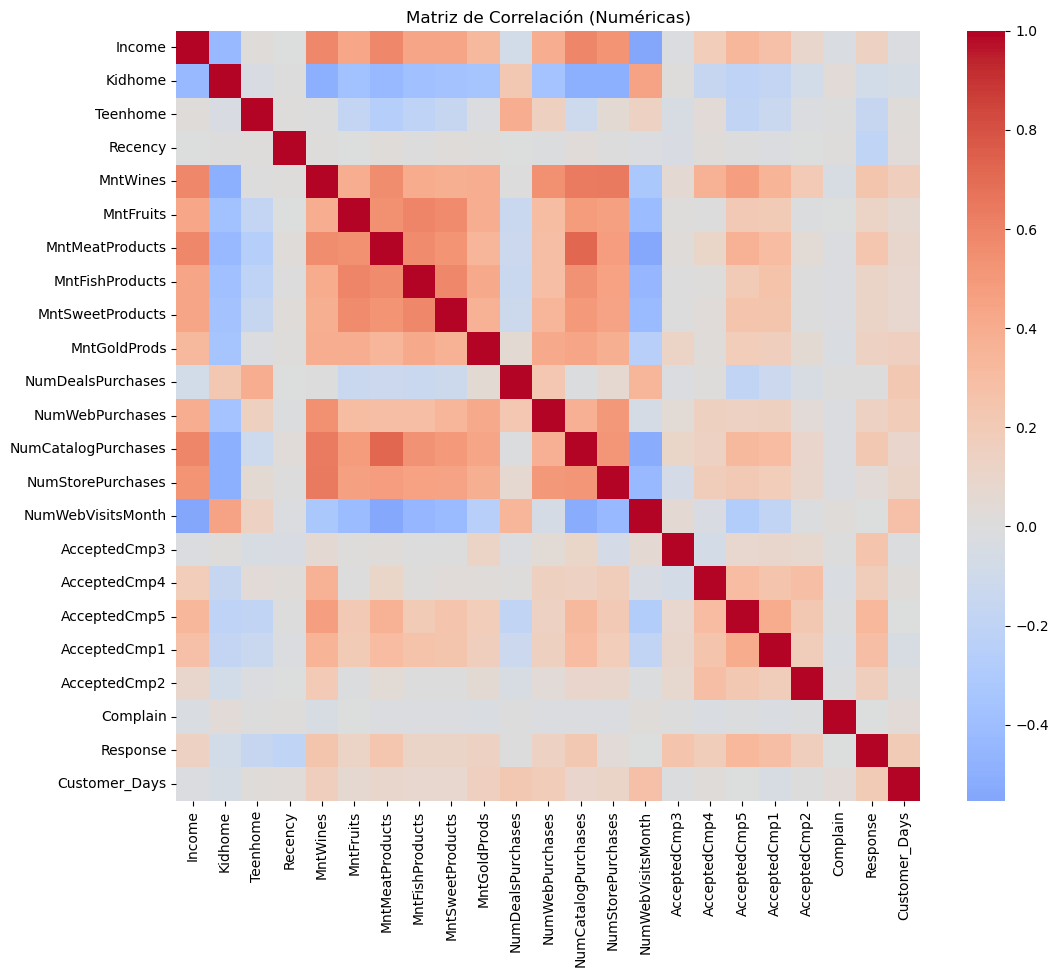

In [41]:
# Solo variables numéricas, aplicamos nuevamente correlación
num_df = df.select_dtypes(include="number")

corr_matrix = num_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación (Numéricas)")
plt.show()

In [42]:
corr_response = corr_matrix["Response"].sort_values(ascending=False)

print("Correlación con Response:")
print(corr_response)

Correlación con Response:
Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
Customer_Days          0.194481
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Name: Response, dtype: float64


In [43]:
corr_spearman = num_df.corr(method="spearman")

print(corr_spearman["Response"].sort_values(ascending=False))

Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
NumCatalogPurchases    0.233216
MntMeatProducts        0.223192
MntWines               0.199046
Customer_Days          0.194673
MntGoldProds           0.183334
AcceptedCmp4           0.177019
NumWebPurchases        0.172775
AcceptedCmp2           0.169293
Income                 0.161100
MntFruits              0.148925
MntSweetProducts       0.136569
MntFishProducts        0.115421
NumStorePurchases      0.053361
NumWebVisitsMonth      0.010737
Complain              -0.001707
NumDealsPurchases     -0.035921
Kidhome               -0.077464
Teenhome              -0.159310
Recency               -0.198169
Name: Response, dtype: float64


In [44]:
df["Complain"].value_counts(normalize=True)

Complain
0    0.990625
1    0.009375
Name: proportion, dtype: float64

Muy pocos clientes se quejan, variable muy desbalanceada. Es casi constante, se puede eliminar.

In [45]:
cols_to_drop = [
    "Complain"
]

df = df.drop(columns=cols_to_drop, errors="ignore")

In [46]:
target = "Response"
X = df.drop(columns=[target])
y = df[target]

# recomputar columnas
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# reconstruir preprocess (clave)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

In [47]:
# SVM RBF SIN reducción + GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = Pipeline([
    ("prep", preprocess),
    ("model", SVC(
        kernel="rbf",
        probability=True,        
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "model__C":    [0.01, 0.1, 1, 10, 100, 1000],
    "model__gamma":[1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"],
}

gs_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

gs_svm.fit(X, y)

print("\nBest ROC-AUC (SVM sin reducción):", gs_svm.best_score_)
print("Best Params:", gs_svm.best_params_)
print("Best Estimator:", gs_svm.best_estimator_)

# Top 10 combinaciones
res = gs_svm.cv_results_
top_idx = np.argsort(res["mean_test_score"])[::-1][:10]
print("\nTop 10 (mean ROC-AUC):")
for i in top_idx:
    print(f"{res['mean_test_score'][i]:.5f} ± {res['std_test_score'][i]:.5f} | {res['params'][i]}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best ROC-AUC (SVM sin reducción): 0.9105419610861955
Best Params: {'model__C': 10, 'model__gamma': 0.01}
Best Estimator: Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Kidhome',
                                                   'Teenhome', 'Recency',
                                                   'MntWines', 'MntFruits',
                                                   'MntMeatProducts',
                                                   'MntFishProducts',
                           

In [48]:
# PCA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_pca = Pipeline([
    ("prep", preprocess),
    ("pca", PCA()),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

param_grid_pca = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 1e-3, 1e-2, 1e-1]
}

gs_pca = GridSearchCV(
    pipe_pca,
    param_grid_pca,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

gs_pca.fit(X, y)

print("Best ROC-AUC (PCA):", gs_pca.best_score_)
print("Best Params:", gs_pca.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best ROC-AUC (PCA): 0.9053275896971424
Best Params: {'model__C': 1, 'model__gamma': 'scale', 'pca__n_components': 0.99}


In [49]:
from sklearn.feature_selection import mutual_info_classif

pipe_skb = Pipeline([
    ("prep", preprocess),
    ("skb", SelectKBest(score_func=mutual_info_classif)),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

param_grid_skb = {
    "skb__k": [10, 15, 20, 25, 30],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 1e-3, 1e-2, 1e-1]
}

gs_skb = GridSearchCV(
    pipe_skb,
    param_grid_skb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

gs_skb.fit(X, y)

print("Best ROC-AUC (SelectKBest):", gs_skb.best_score_)
print("Best Params:", gs_skb.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best ROC-AUC (SelectKBest): 0.9051959598843433
Best Params: {'model__C': 10, 'model__gamma': 0.01, 'skb__k': 30}


In [50]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x,
    accept_sparse=True
)

pipe_lda = Pipeline([
    ("prep", preprocess),
    ("to_dense", to_dense),
    ("lda", LinearDiscriminantAnalysis()),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

param_grid_lda = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 1e-3, 1e-2, 1e-1]
}

gs_lda = GridSearchCV(
    pipe_lda,
    param_grid_lda,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

gs_lda.fit(X, y)

print("Best ROC-AUC (LDA):", gs_lda.best_score_)
print("Best Params:", gs_lda.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best ROC-AUC (LDA): 0.8889585761560861
Best Params: {'model__C': 0.1, 'model__gamma': 0.001}


# Conclusión del análisis y modelado

Durante el proceso se evaluaron distintas estrategias de **ingeniería de variables** y **reducción de dimensionalidad** con el objetivo de mejorar el desempeño del modelo de clasificación sobre la variable objetivo **Response**.

Se compararon cuatro configuraciones principales utilizando **Logistic Regression**:

- Modelo base (**sin reducción de dimensionalidad**)
- **PCA** (Principal Component Analysis)
- **LDA** (Linear Discriminant Analysis)
- **SelectKBest** (selección de variables)

---

## Resultados obtenidos

| Modelo | Mean ROC-AUC | Desvío estándar |
|------|------|------|
| Baseline | **0.9066** | 0.0140 |
| PCA | 0.8954 | 0.0201 |
| LDA | 0.8590 | 0.0204 |
| SelectKBest | 0.8788 | 0.0179 |

Los resultados muestran que **ninguna técnica de reducción de dimensionalidad superó al modelo base**, lo que indica que las variables originales del dataset ya contienen una estructura informativa adecuada para el problema.

---

# Evaluación con Support Vector Machine

Posteriormente se evaluó un modelo **Support Vector Machine (SVM)** con **kernel RBF**, utilizando **GridSearch** para optimizar los hiperparámetros.

El mejor resultado obtenido fue:

**ROC-AUC = 0.9105**

Este resultado se alcanzó **sin aplicar reducción de dimensionalidad**, utilizando prácticamente las variables originales del dataset y eliminando únicamente la variable **Complain**.

Esta variable presentaba:

- una distribución extremadamente desbalanceada (≈ **99% de ceros**)
- correlación prácticamente **nula** con la variable objetivo

Por lo tanto, su contribución al modelo era mínima y funcionaba principalmente como **ruido estadístico**.

---

# Interpretación de los resultados

Los resultados obtenidos sugieren que:

- Las **variables originales del dataset contienen suficiente señal predictiva** para modelar el problema.
- Las técnicas de **reducción de dimensionalidad (PCA y LDA)** no aportaron mejoras y, en algunos casos, redujeron el rendimiento del modelo.
- Algunas variables derivadas o combinaciones artificiales pueden introducir **redundancia o ruido**, sin aportar información adicional relevante.
- El modelo **SVM con kernel RBF** logra capturar adecuadamente las **relaciones no lineales presentes en los datos**.

---

# Conclusión general

El mejor desempeño se obtuvo utilizando un **SVM con kernel RBF entrenado sobre las variables originales del dataset**, eliminando únicamente la variable **Complain**, alcanzando un **ROC-AUC de 0.9105**.

Estos resultados sugieren que el dataset posee una **estructura informativa adecuada**, y que en este caso **mantener las variables originales resulta más efectivo que aplicar transformaciones complejas o técnicas de reducción de dimensionalidad**.

En consecuencia, el enfoque final adoptado prioriza:

- simplicidad del conjunto de variables
- interpretabilidad del modelo
- eliminación de variables con **baja varianza o baja señal predictiva**
- uso de un modelo capaz de capturar **relaciones no lineales**, como **SVM con kernel RBF****, como **SVM con kernel RBF**.iminando únicamente la variable:
